# 1. lorenz

Generate a trajectory of the Lorenz system with `nolitisea.generate.lorenz.lorenz` and visualize the 3-D attractor.

`lorenz` integrates the classical Lorenz equations with `scipy.integrate.solve_ivp` (RK45), discards the first `discard` samples to remove transients, and returns the sampled times together with the phase-space points as an array of shape `(length, 3)`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.generate.lorenz import lorenz

np.random.seed(42)

# Generate a trajectory with default parameters.
t, states = lorenz(length=10000)
print(f"times : shape {t.shape}, t = [{t[0]:.3f}, {t[-1]:.3f}]")
print(f"states: shape {states.shape}")
print(f"first point: {states[0]}")

times : shape (10000,), t = [30.000, 329.971]
states: shape (10000, 3)
first point: [-12.02735593 -18.6368082   22.45196292]


## Save the generated data

Write the trajectory to `./data/lorenz.txt` as a plain-text table with one column per component (`x`, `y`, `z`), matching the data-file convention of the original C programs.

In [2]:
from pathlib import Path

data_dir = Path("./data")
data_dir.mkdir(parents=True, exist_ok=True)

out_path = data_dir / "lorenz.txt"
np.savetxt(
    out_path,
    states,
    fmt="%.8f",
    header=(
        "Lorenz trajectory (sigma=10, beta=8/3, rho=28); "
        "columns: x y z; sample interval 0.03"
    ),
)
print(f"saved {states.shape[0]} samples to {out_path}")

saved 10000 samples to data\lorenz.txt


## 3-D attractor

The classic butterfly-shaped Lorenz attractor in phase space:

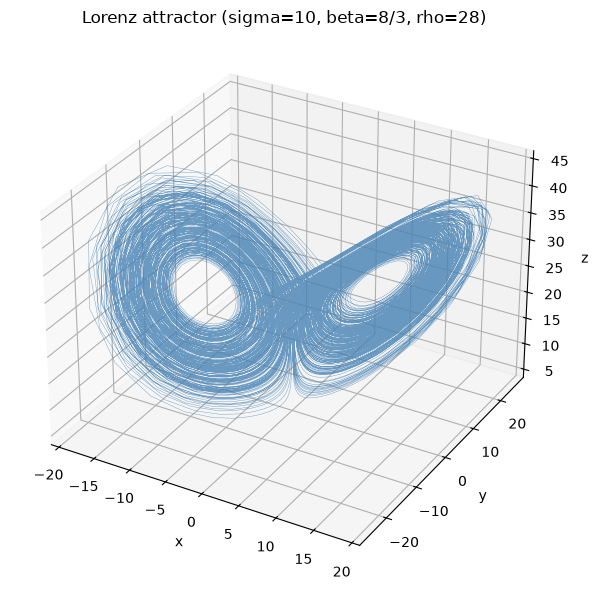

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.plot(
    states[:, 0], states[:, 1], states[:, 2],
    lw=0.3, color="steelblue", alpha=0.8,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz attractor (sigma=10, beta=8/3, rho=28)")

plt.tight_layout()
plt.show()

## Component time series

Each component of the phase-space vector is a scalar time series that can be fed into the analysis routines of the package:

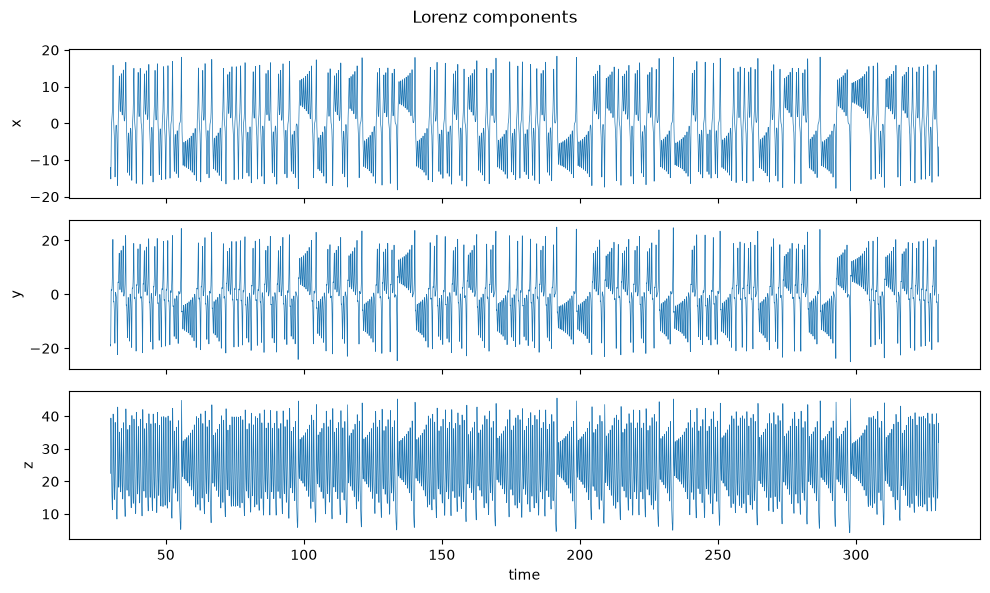

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

for ax, name, series in zip(axes, "xyz", states.T):
    ax.plot(t, series, lw=0.5)
    ax.set_ylabel(name)

axes[-1].set_xlabel("time")
fig.suptitle("Lorenz components")

plt.tight_layout()
plt.show()

# 2. henon

Generate a Hénon-map time series with `nolitisea.generate.henon.henon` and visualise the 2-D attractor.

The Hénon map is a discrete-time dynamical system defined by `x_{n+1} = 1 - a * x_n^2 + b * y_n`, `y_{n+1} = x_n`.  With the classic parameters `a=1.4, b=0.3` it produces a strange attractor.  `henon` discards transients and returns two 1-D arrays `X, Y` of length `n`.

In [5]:
from nolitisea.generate.henon import henon

# Generate a Hénon-map trajectory with default parameters.
X, Y = henon(n=10000)
print(f'X: shape {X.shape}, range [{X.min():.3f}, {X.max():.3f}]')
print(f'Y: shape {Y.shape}, range [{Y.min():.3f}, {Y.max():.3f}]')

X: shape (10000,), range [-1.285, 1.273]
Y: shape (10000,), range [-1.285, 1.273]


## 2-D attractor

The classic Hénon strange attractor in the `(x, y)` plane:

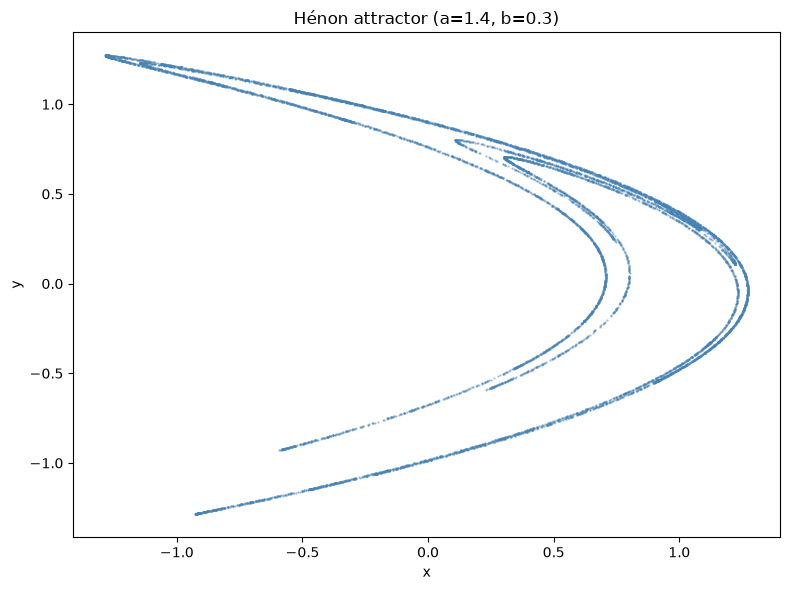

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X, Y, s=0.5, c='steelblue', alpha=0.4)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Hénon attractor (a=1.4, b=0.3)')

plt.tight_layout()
plt.show()

## Component time series

The first 200 iterations of each component:

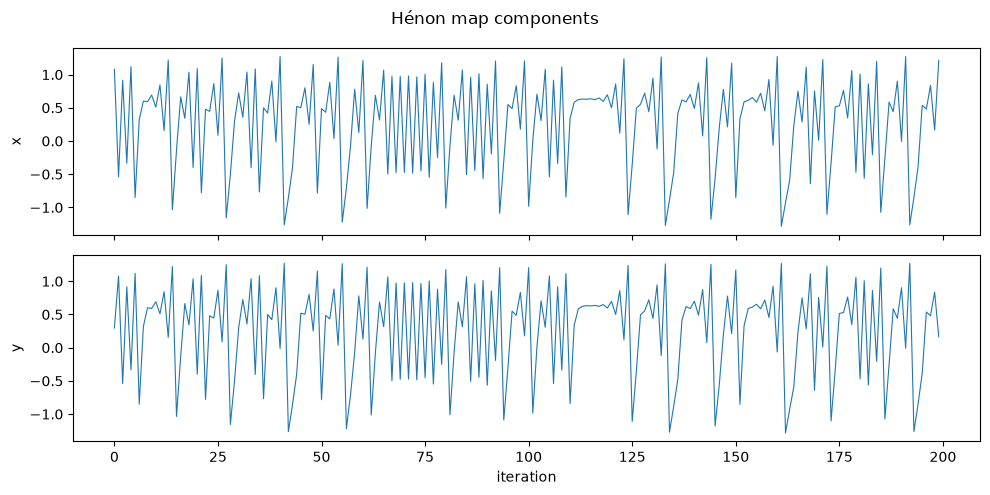

In [7]:
n_show = 200
iters = np.arange(n_show)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(iters, X[:n_show], lw=0.8)
axes[0].set_ylabel('x')
axes[1].plot(iters, Y[:n_show], lw=0.8)
axes[1].set_ylabel('y')
axes[1].set_xlabel('iteration')
fig.suptitle('Hénon map components')

plt.tight_layout()
plt.show()

## Save the Hénon-map data

Write the trajectory to `./data/henon.txt` as a plain-text table with one column per component (`x`, `y`), matching the data-file convention of the Lorenz section above.

In [8]:
data_dir = Path('./data')
data_dir.mkdir(parents=True, exist_ok=True)

henon_path = data_dir / 'henon.txt'
np.savetxt(
    henon_path,
    np.column_stack([X, Y]),
    fmt='%.8f',
    header='Hénon map (a=1.4, b=0.3); columns: x y',
)
print(f'saved {X.shape[0]} samples to {henon_path}')

saved 10000 samples to data\henon.txt


# 3. ikeda

Generate a trajectory of the Ikeda map with `nolitisea.generate.ikeda.ikeda` and visualise the 2-D attractor.

The Ikeda map is a discrete-time 2-D map written most compactly with a complex state `z = x + i y`:

    z_{n+1} = gamma + mu * z_n * exp(i * (beta - alpha / (1 + |z_n|^2)))

With the classic parameters `alpha=6.0, beta=0.4, gamma=1.0, mu=0.9` it produces a well-known strange attractor.  Transients are discarded and the trajectory is returned as an array of shape `(length, 2)` with one row per `(x_n, y_n)` point.

In [9]:
from nolitisea.generate.ikeda import ikeda

np.random.seed(42)

# Generate an Ikeda-map trajectory with default parameters.
ikeda_pts = ikeda(length=10000)
print(f"points: shape {ikeda_pts.shape}")
print(f"x range: [{ikeda_pts[:, 0].min():.3f}, {ikeda_pts[:, 0].max():.3f}]")
print(f"y range: [{ikeda_pts[:, 1].min():.3f}, {ikeda_pts[:, 1].max():.3f}]")

points: shape (10000, 2)
x range: [-0.352, 1.702]
y range: [-2.193, 0.864]


## 2-D attractor

The Ikeda strange attractor in the `(x, y)` plane:

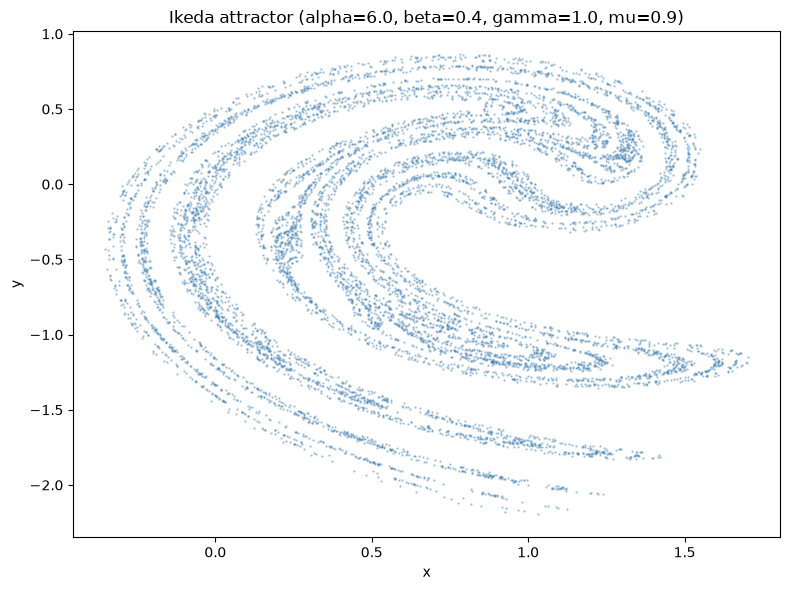

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(ikeda_pts[:, 0], ikeda_pts[:, 1],
           s=0.5, c="steelblue", alpha=0.4)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Ikeda attractor (alpha=6.0, beta=0.4, gamma=1.0, mu=0.9)")

plt.tight_layout()
plt.show()

## Component time series

The first 200 iterations of each component:

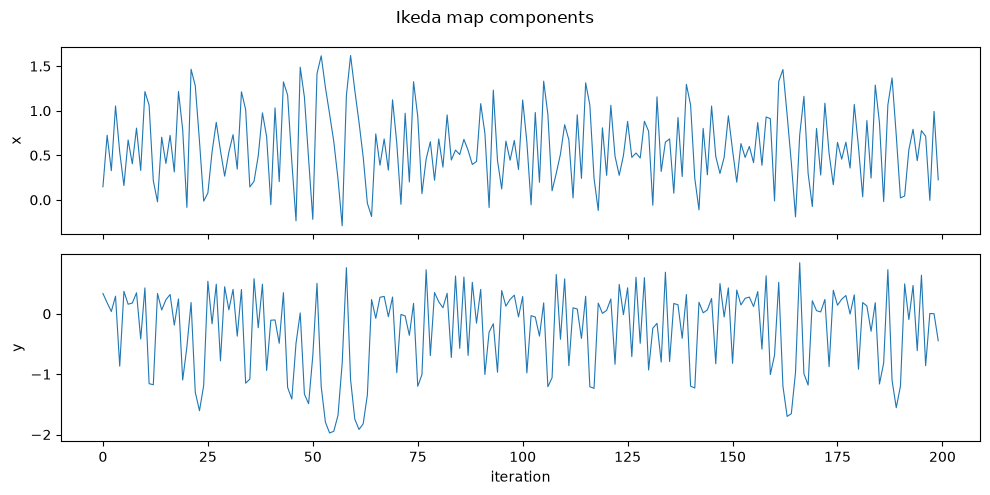

In [11]:
n_show = 200
iters = np.arange(n_show)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(iters, ikeda_pts[:n_show, 0], lw=0.8)
axes[0].set_ylabel("x")
axes[1].plot(iters, ikeda_pts[:n_show, 1], lw=0.8)
axes[1].set_ylabel("y")
axes[1].set_xlabel("iteration")
fig.suptitle("Ikeda map components")

plt.tight_layout()
plt.show()

## Save the Ikeda-map data

Write the trajectory to `./data/ikeda.txt` as a plain-text table with one column per component (`x`, `y`), matching the data-file convention of the sections above.

In [12]:
data_dir = Path("./data")
data_dir.mkdir(parents=True, exist_ok=True)

ikeda_path = data_dir / "ikeda.txt"
np.savetxt(
    ikeda_path,
    ikeda_pts,
    fmt="%.8f",
    header="Ikeda map (alpha=6.0, beta=0.4, gamma=1.0, mu=0.9); columns: x y",
)
print(f"saved {ikeda_pts.shape[0]} samples to {ikeda_path}")

saved 10000 samples to data\ikeda.txt


# 4. mackey_glass

Generate a Mackey-Glass time series with `nolitisea.generate.mackey_glass.mackey_glass`.

The Mackey-Glass system is a delay differential equation

    dx/dt = -b*x(t) + a * x(t-tau) / (1 + x(t-tau)^c)

integrated with the trapezoidal scheme of Grassberger & Procaccia (1983).  The delay interval `tau` is split into `n` sub-steps internally and the trajectory is subsampled every `sample` time units.  With the default delay `tau=23` the system is chaotic; the output is a 1-D scalar series of length `length`.

In [13]:
from nolitisea.generate.mackey_glass import mackey_glass

np.random.seed(42)

# Generate a Mackey-Glass series with the default (chaotic) parameters.
mg = mackey_glass(length=10000)
print(f"series: shape {mg.shape}")
print(f"range: [{mg.min():.3f}, {mg.max():.3f}]")
print(f"delay tau=23.0, sampling interval sample=0.46 "
      f"-> delay is ~{23.0 / 0.46:.0f} samples")

series: shape (10000,)
range: [0.291, 1.355]
delay tau=23.0, sampling interval sample=0.46 -> delay is ~50 samples


## Time series

The irregular, aperiodic oscillations of the chaotic delay system (first 1500 samples):

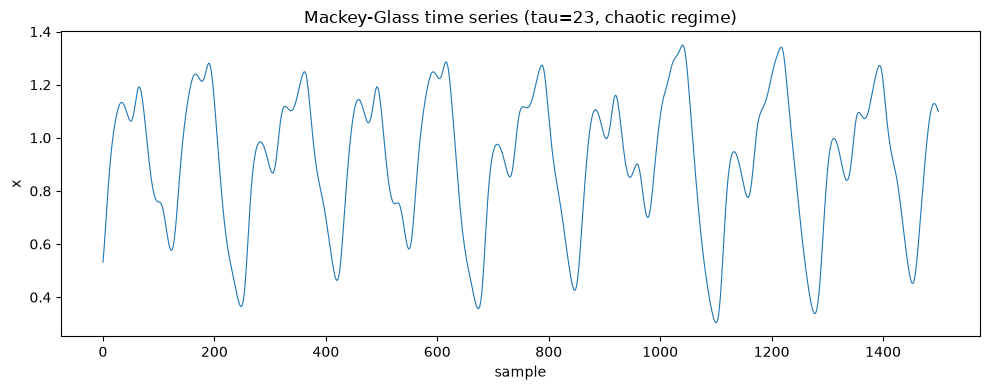

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(1500), mg[:1500], lw=0.8)
ax.set_xlabel("sample")
ax.set_ylabel("x")
ax.set_title("Mackey-Glass time series (tau=23, chaotic regime)")

plt.tight_layout()
plt.show()

## Phase-space reconstruction

Because the output is scalar, the attractor is visualised through a delay embedding `x(t)` versus `x(t - lag)`.  Using one delay interval (`lag = tau / sample = 50` samples) unfolds the characteristic spiral structure of the Mackey-Glass attractor:

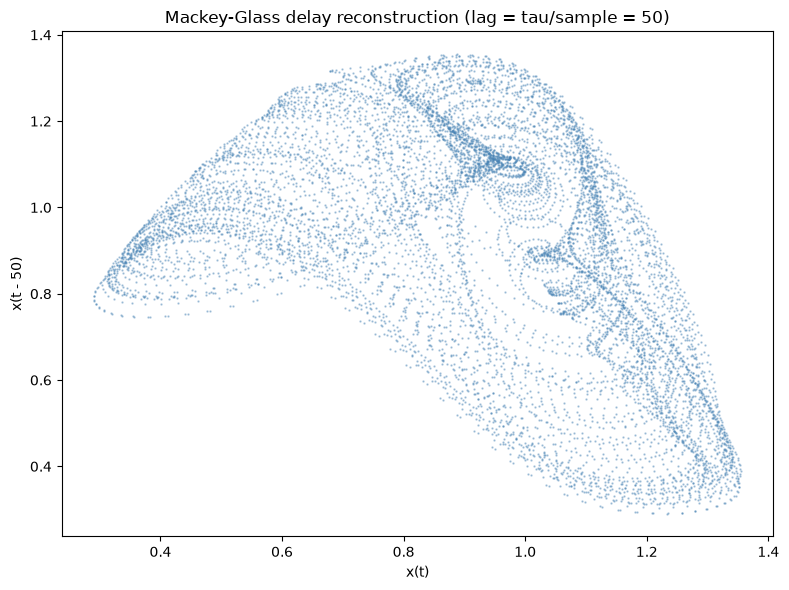

In [15]:
lag = 50  # samples, corresponding to one delay interval tau

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(mg[:-lag], mg[lag:], s=0.5, c="steelblue", alpha=0.4)
ax.set_xlabel("x(t)")
ax.set_ylabel(f"x(t - {lag})")
ax.set_title("Mackey-Glass delay reconstruction (lag = tau/sample = 50)")

plt.tight_layout()
plt.show()

## Save the Mackey-Glass data

Write the scalar series to `./data/mackey_glass.txt` as a single-column plain-text file, matching the data-file convention of the sections above.

In [16]:
data_dir = Path("./data")
data_dir.mkdir(parents=True, exist_ok=True)

mg_path = data_dir / "mackey_glass.txt"
np.savetxt(
    mg_path,
    mg,
    fmt="%.8f",
    header="Mackey-Glass series (a=0.2, b=0.1, c=10.0, tau=23.0); column: x",
)
print(f"saved {mg.shape[0]} samples to {mg_path}")

saved 10000 samples to data\mackey_glass.txt


# 5. roessler

Generate a trajectory of the Rossler oscillator with `nolitisea.generate.roessler.roessler` and visualise the 3-D attractor.

The Rossler system is defined by

    dx/dt = -(y + z)
    dy/dt = x + a*y
    dz/dt = b + z*(x - c)

and is integrated with `scipy.integrate.odeint`, discarding the first `discard` samples.  With the classic parameters `a=0.2, b=0.2, c=5.7` it produces a spiral-shaped strange attractor.  The function returns the sampled times and the phase-space points as an array of shape `(length, 3)`.

In [17]:
from nolitisea.generate.roessler import roessler

np.random.seed(42)

# Generate a Rossler trajectory with default parameters.
t_ros, ros = roessler(length=10000)
print(f"times : shape {t_ros.shape}, t = [{t_ros[0]:.3f}, {t_ros[-1]:.3f}]")
print(f"states: shape {ros.shape}")
print(f"first point: {ros[0]}")

times : shape (10000,), t = [100.000, 1099.901]
states: shape (10000, 3)
first point: [-5.3172526  -4.44634852  0.01761875]


## 3-D attractor

The classic spiral-shaped Rossler attractor in phase space:

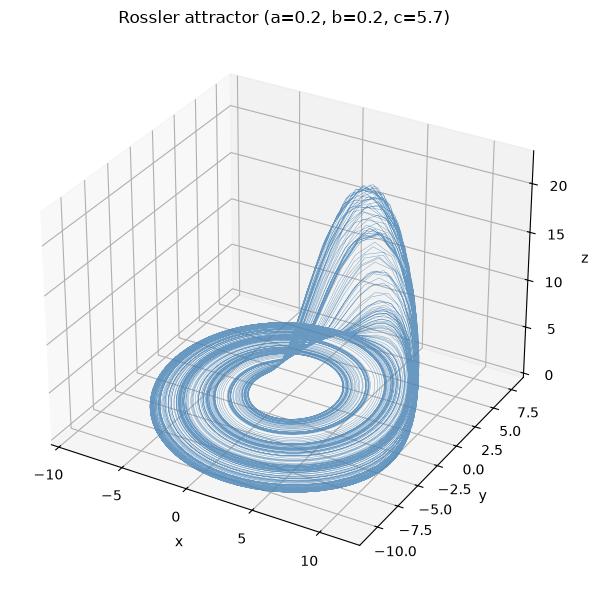

In [18]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.plot(
    ros[:, 0], ros[:, 1], ros[:, 2],
    lw=0.3, color="steelblue", alpha=0.8,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Rossler attractor (a=0.2, b=0.2, c=5.7)")

plt.tight_layout()
plt.show()

## Component time series

Each component of the phase-space vector is a scalar time series that can be fed into the analysis routines of the package:

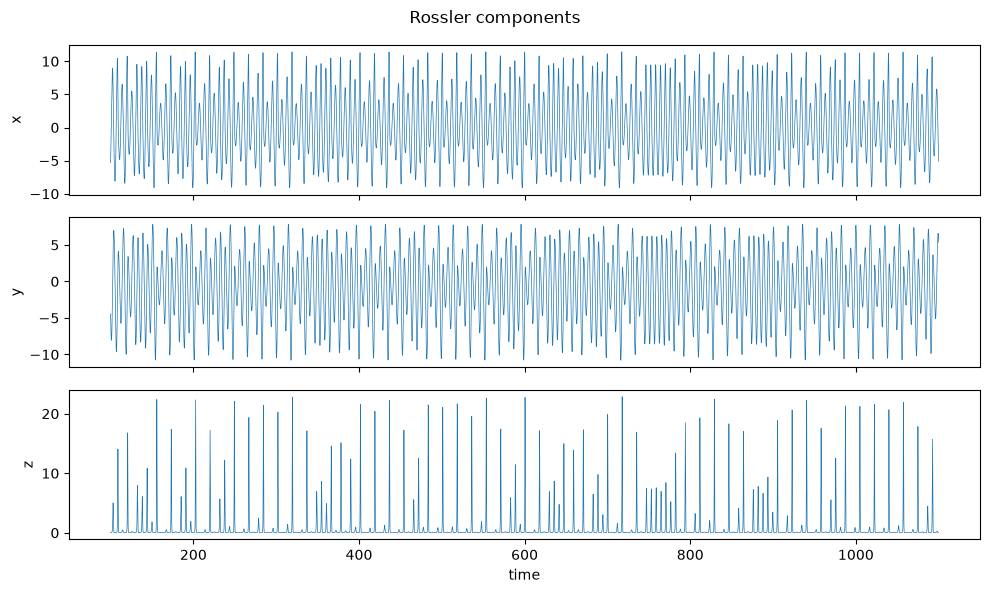

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

for ax, name, series in zip(axes, "xyz", ros.T):
    ax.plot(t_ros, series, lw=0.5)
    ax.set_ylabel(name)

axes[-1].set_xlabel("time")
fig.suptitle("Rossler components")

plt.tight_layout()
plt.show()

## Save the Rossler data

Write the trajectory to `./data/roessler.txt` as a plain-text table with one column per component (`x`, `y`, `z`), matching the data-file convention of the sections above.

In [20]:
data_dir = Path("./data")
data_dir.mkdir(parents=True, exist_ok=True)

roessler_path = data_dir / "roessler.txt"
np.savetxt(
    roessler_path,
    ros,
    fmt="%.8f",
    header=(
        "Rossler trajectory (a=0.2, b=0.2, c=5.7); "
        "columns: x y z; sample interval 0.1"
    ),
)
print(f"saved {ros.shape[0]} samples to {roessler_path}")

saved 10000 samples to data\roessler.txt
